In [114]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

import torch
from torch import nn

from timeit import default_timer as timer


torch.use_deterministic_algorithms(True)


device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cuda


In [115]:
data = pd.read_excel(
    "final_catalog.xlsx"
)


data.info()


data.head()

<class 'pandas.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   event_id    772 non-null    int64  
 1   event_time  772 non-null    str    
 2   latitude    772 non-null    float64
 3   longitude   772 non-null    float64
 4   depth       772 non-null    float64
 5   magnitude   772 non-null    float64
 6   natprob     772 non-null    float64
 7   cluster     772 non-null    int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 48.4 KB


,event_id,event_time,latitude,longitude,depth,magnitude,natprob,cluster
0,4,2019-10-12T13:10:03.100000Z,28.261995,102.289697,0.410,-0.855,0.577,3
1,7,2019-10-13T00:25:26.350000Z,28.472400,102.219600,6.680,-1.170,0.772,0
2,11,2019-10-13T13:25:02.510000Z,28.259794,102.283586,1.063,-0.824,0.669,3
3,12,2019-10-13T13:27:52.980000Z,28.258500,102.287500,1.910,-0.839,0.675,3
4,23,2019-10-14T10:23:34.500000Z,28.356618,102.262459,1.568,-1.032,0.624,1


In [116]:
required_columns = [
    "latitude",
    "longitude",
    "depth",
    "natprob",
    "magnitude"
]


data = data[
    required_columns
].dropna()


print(
    "Cantidad de registros utilizados:",
    len(data)
)


data.head()

Cantidad de registros utilizados: 772


,latitude,longitude,depth,natprob,magnitude
0,28.261995,102.289697,0.410,0.577,-0.855
1,28.472400,102.219600,6.680,0.772,-1.170
2,28.259794,102.283586,1.063,0.669,-0.824
3,28.258500,102.287500,1.910,0.675,-0.839
4,28.356618,102.262459,1.568,0.624,-1.032


In [117]:
X = data.drop(
    "magnitude",
    axis=1
)


y = data[
    "magnitude"
]


print(
    "Características de entrada:"
)

print(
    X.columns.tolist()
)


print(
    "\nForma de X:",
    X.shape
)


print(
    "Forma de y:",
    y.shape
)

Características de entrada:
['latitude', 'longitude', 'depth', 'natprob']

Forma de X: (772, 4)
Forma de y: (772,)


In [118]:
# Data splitting:
# 60% training
# 20% validation
# 20% testing


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42
)


print(
    "Entrenamiento:"
)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)


print(
    "\nValidación:"
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)


print(
    "\nPrueba:"
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

Entrenamiento:
X_train: (463, 4)
y_train: (463,)

Validación:
X_val: (154, 4)
y_val: (154,)

Prueba:
X_test: (155, 4)
y_test: (155,)


In [119]:
Data_train = pd.concat(
    [
        X_train,
        y_train
    ],
    axis=1
)


# Spearman correlation

Spearman_corr = Data_train.corr(
    method="spearman"
)


print(
    Spearman_corr[
        "magnitude"
    ]
    .abs()
    .sort_values(
        ascending=False
    )
)

magnitude    1.000000
latitude     0.341463
longitude    0.228657
depth        0.215190
natprob      0.102981
Name: magnitude, dtype: float64


In [120]:
Interesting_features = [
    "latitude",
    "longitude",
    "depth",
    "natprob"
]


number_of_features = len(
    Interesting_features
)


X_train = X_train[
    Interesting_features
]

X_val = X_val[
    Interesting_features
]

X_test = X_test[
    Interesting_features
]


print(
    "Características utilizadas:"
)

print(
    Interesting_features
)


print(
    "\nNúmero de características:",
    number_of_features
)

Características utilizadas:
['latitude', 'longitude', 'depth', 'natprob']

Número de características: 4


In [121]:
# Normalization


scaler = MinMaxScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_val_scaled = scaler.transform(
    X_val
)


X_test_scaled = scaler.transform(
    X_test
)


print(
    "Mínimo de entrenamiento:",
    X_train_scaled.min()
)


print(
    "Máximo de entrenamiento:",
    X_train_scaled.max()
)

Mínimo de entrenamiento: 0.0
Máximo de entrenamiento: 1.0


In [122]:
y_train = y_train.values

y_val = y_val.values

y_test = y_test.values


print(
    "X_train_scaled:",
    X_train_scaled.shape
)


print(
    "y_train:",
    y_train.shape
)


print(
    "X_val_scaled:",
    X_val_scaled.shape
)


print(
    "y_val:",
    y_val.shape
)


print(
    "X_test_scaled:",
    X_test_scaled.shape
)


print(
    "y_test:",
    y_test.shape
)

X_train_scaled: (463, 4)
y_train: (463,)
X_val_scaled: (154, 4)
y_val: (154,)
X_test_scaled: (155, 4)
y_test: (155,)


In [123]:
class RegressionModel(nn.Module):

    def __init__(
        self,
        number_of_features,
        hidden_layer_size1,
        hidden_layer_size2,
        hidden_layer_size3,
        number_of_outputs
    ):

        super().__init__()


        self.layer_input = nn.Linear(
            number_of_features,
            hidden_layer_size1
        )
        # w*x+b


        self.hidden_layer_1 = nn.Linear(
            hidden_layer_size1,
            hidden_layer_size2
        )


        self.hidden_layer_2 = nn.Linear(
            hidden_layer_size2,
            hidden_layer_size3
        )


        self.layer_output = nn.Linear(
            hidden_layer_size3,
            number_of_outputs
        )


        self.tanh = nn.Tanh()


    def forward(self, x):

        x = self.tanh(
            self.layer_input(x)
        )


        x = self.tanh(
            self.hidden_layer_1(x)
        )


        x = self.tanh(
            self.hidden_layer_2(x)
        )


        return self.layer_output(x)

In [124]:
def train_step(
    model,
    loss_fn,
    X_train,
    y_train,
    optimizer,
    device=device
):


    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)


    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)


    model.train()


    y_pred = model(
        X_train
    ).squeeze()


    train_loss = loss_fn(
        y_pred,
        y_train
    )


    train_mae = torch.mean(
        torch.abs(
            y_pred - y_train
        )
    ).item()


    optimizer.zero_grad()


    train_loss.backward()


    optimizer.step()


    return (
        train_loss.item(),
        train_mae
    )

In [125]:
def val_step(
    model,
    X_val,
    y_val,
    loss_fn,
    optimizer,
    device=device
):


    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    ).to(device)


    y_val = torch.tensor(
        y_val,
        dtype=torch.float32
    ).to(device)


    model.eval()


    with torch.inference_mode():


        val_pred = model(
            X_val
        ).squeeze()


        val_loss = loss_fn(
            val_pred,
            y_val
        )


        val_mae = torch.mean(
            torch.abs(
                val_pred - y_val
            )
        ).item()


    return (
        val_loss.item(),
        val_mae
    )

In [126]:
def train(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer,
    loss_fn,
    epochs,
    device=device
):


    results = {
        "train_loss": [],
        "train_mae": [],
        "val_loss": [],
        "val_mae": []
    }


    best_val_loss = torch.inf


    MODEL_PATH = "model_trained/"


    for epoch in range(epochs):


        train_loss, train_mae = train_step(
            model=model,
            X_train=X_train,
            y_train=y_train,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )


        val_loss, val_mae = val_step(
            model=model,
            X_val=X_val,
            y_val=y_val,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )


        if val_loss < best_val_loss:


            best_val_loss = val_loss


            MODEL_NAME = (
                "regressor_replicas.pth"
            )


            MODEL_SAVE_PATH = (
                MODEL_PATH
                + MODEL_NAME
            )


            torch.save(
                model.state_dict(),
                MODEL_SAVE_PATH
            )


        print(
            f"Epoch: {epoch} | "
            f"Train loss: "
            f"{train_loss:.4f} "
            f"Train MAE: "
            f"{train_mae:.4f} | "
            f"Val loss: "
            f"{val_loss:.4f} "
            f"Val MAE: "
            f"{val_mae:.4f}"
        )


        results[
            "train_loss"
        ].append(
            train_loss
        )


        results[
            "train_mae"
        ].append(
            train_mae
        )


        results[
            "val_loss"
        ].append(
            val_loss
        )


        results[
            "val_mae"
        ].append(
            val_mae
        )


    return results

In [127]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)


NUM_EPOCHS = 1500


HIDDEN_LAYER_SIZE1 = 10

HIDDEN_LAYER_SIZE2 = 6

HIDDEN_LAYER_SIZE3 = 4


model = RegressionModel(
    number_of_features=number_of_features,
    hidden_layer_size1=HIDDEN_LAYER_SIZE1,
    hidden_layer_size2=HIDDEN_LAYER_SIZE2,
    hidden_layer_size3=HIDDEN_LAYER_SIZE3,
    number_of_outputs=1
).to(device)


loss_fn = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=0.0001
)


print(model)

RegressionModel(
  (layer_input): Linear(in_features=4, out_features=10, bias=True)
  (hidden_layer_1): Linear(in_features=10, out_features=6, bias=True)
  (hidden_layer_2): Linear(in_features=6, out_features=4, bias=True)
  (layer_output): Linear(in_features=4, out_features=1, bias=True)
  (tanh): Tanh()
)


In [128]:
start_time = timer()


model_results = train(
    model=model,
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val_scaled,
    y_val=y_val,
    device=device,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS
)


end_time = timer()


print(
    f"Total training time "
    f"{end_time - start_time:.3f} "
    f"seconds"
)

Epoch: 0 | Train loss: 1.8128 Train MAE: 1.2812 | Val loss: 1.7093 Val MAE: 1.2392
Epoch: 1 | Train loss: 1.7356 Train MAE: 1.2512 | Val loss: 1.6349 Val MAE: 1.2101
Epoch: 2 | Train loss: 1.6604 Train MAE: 1.2213 | Val loss: 1.5625 Val MAE: 1.1817
Epoch: 3 | Train loss: 1.5872 Train MAE: 1.1915 | Val loss: 1.4923 Val MAE: 1.1536
Epoch: 4 | Train loss: 1.5161 Train MAE: 1.1620 | Val loss: 1.4243 Val MAE: 1.1259
Epoch: 5 | Train loss: 1.4473 Train MAE: 1.1327 | Val loss: 1.3584 Val MAE: 1.0985


Epoch: 6 | Train loss: 1.3808 Train MAE: 1.1039 | Val loss: 1.2947 Val MAE: 1.0713
Epoch: 7 | Train loss: 1.3164 Train MAE: 1.0756 | Val loss: 1.2330 Val MAE: 1.0445
Epoch: 8 | Train loss: 1.2539 Train MAE: 1.0481 | Val loss: 1.1729 Val MAE: 1.0179
Epoch: 9 | Train loss: 1.1932 Train MAE: 1.0210 | Val loss: 1.1145 Val MAE: 0.9914
Epoch: 10 | Train loss: 1.1341 Train MAE: 0.9940 | Val loss: 1.0575 Val MAE: 0.9648
Epoch: 11 | Train loss: 1.0765 Train MAE: 0.9672 | Val loss: 1.0019 Val MAE: 0.9380
Epoch: 12 | Train loss: 1.0202 Train MAE: 0.9407 | Val loss: 0.9476 Val MAE: 0.9109
Epoch: 13 | Train loss: 0.9654 Train MAE: 0.9141 | Val loss: 0.8947 Val MAE: 0.8836
Epoch: 14 | Train loss: 0.9119 Train MAE: 0.8874 | Val loss: 0.8431 Val MAE: 0.8560
Epoch: 15 | Train loss: 0.8598 Train MAE: 0.8609 | Val loss: 0.7931 Val MAE: 0.8286
Epoch: 16 | Train loss: 0.8092 Train MAE: 0.8344 | Val loss: 0.7445 Val MAE: 0.8009
Epoch: 17 | Train loss: 0.7601 Train MAE: 0.8079 | Val loss: 0.6976 Val MAE: 0.7

In [129]:
def plot_loss_curves(results):


    train_loss = results[
        "train_loss"
    ]


    val_loss = results[
        "val_loss"
    ]


    train_mae = results[
        "train_mae"
    ]


    val_mae = results[
        "val_mae"
    ]


    epochs = range(
        len(train_loss)
    )


    plt.figure(
        figsize=(15, 7)
    )


    plt.subplot(
        1,
        2,
        1
    )


    plt.plot(
        epochs,
        train_loss,
        label="train_loss"
    )


    plt.plot(
        epochs,
        val_loss,
        label="val_loss"
    )


    plt.title(
        "Loss"
    )


    plt.xlabel(
        "Epochs"
    )


    plt.legend()


    plt.subplot(
        1,
        2,
        2
    )


    plt.plot(
        epochs,
        train_mae,
        label="train_mae"
    )


    plt.plot(
        epochs,
        val_mae,
        label="val_mae"
    )


    plt.title(
        "Mean Absolute Error"
    )


    plt.xlabel(
        "Epochs"
    )


    plt.legend()


    plt.show()

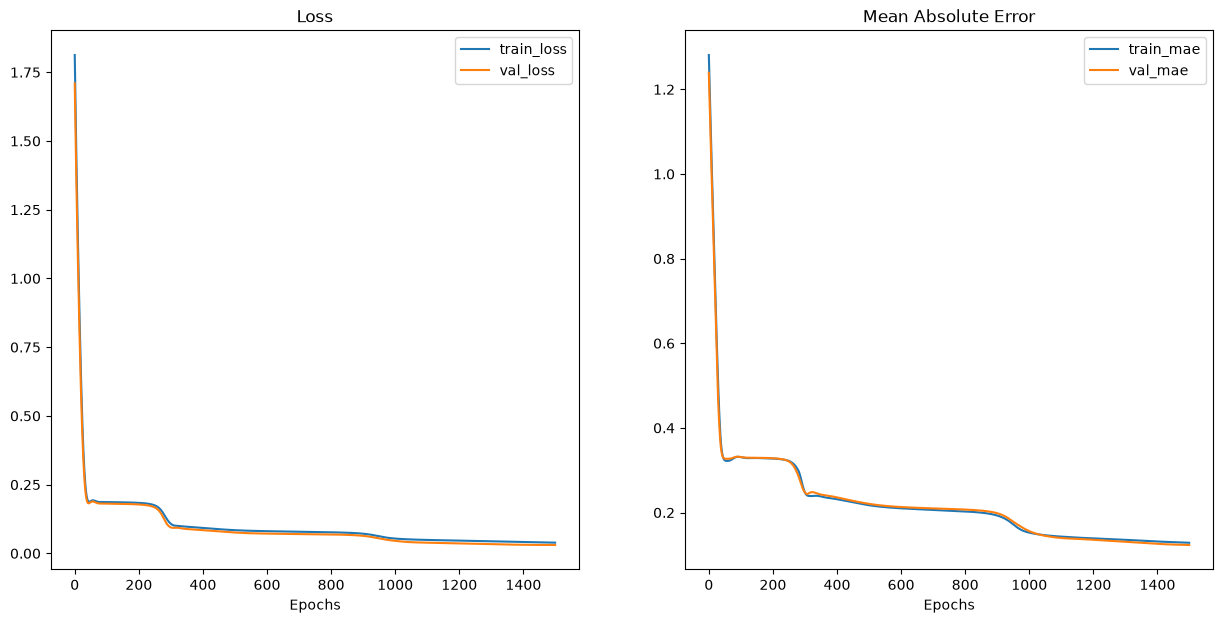

In [130]:
plot_loss_curves(
    model_results
)

In [131]:
model = RegressionModel(
    number_of_features=number_of_features,
    hidden_layer_size1=HIDDEN_LAYER_SIZE1,
    hidden_layer_size2=HIDDEN_LAYER_SIZE2,
    hidden_layer_size3=HIDDEN_LAYER_SIZE3,
    number_of_outputs=1
).to(device)


MODEL_PATH = "model_trained/"


MODEL_NAME = (
    "regressor_replicas.pth"
)


MODEL_SAVE_PATH = (
    MODEL_PATH
    + MODEL_NAME
)


model.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=device
    )
)


print(
    "Modelo cargado correctamente"
)

Modelo cargado correctamente


In [132]:
model.eval()


with torch.inference_mode():


    y_test_pred = model(
        torch.tensor(
            X_test_scaled,
            dtype=torch.float32
        ).to(device)
    ).squeeze()


    y_test_pred = (
        y_test_pred
        .cpu()
        .numpy()
    )


y_test_pred

array([-1.2241734 , -1.1984235 , -1.168694  , -0.51510835, -1.1040864 ,
       -1.239894  , -1.2035222 ,  0.12936696, -0.7689626 , -1.1915443 ,
       -1.1323315 , -1.2001116 , -0.7330004 , -1.205029  ,  0.2977558 ,
       -1.2240019 , -0.791383  , -1.2449269 , -0.788694  , -0.52537847,
       -0.59860015, -1.1964082 , -0.60824215, -0.11178485, -0.76442194,
       -1.2310026 , -0.80849206, -0.82292557, -0.63779426, -0.8227036 ,
       -1.2028778 , -0.7758956 , -0.77837   , -0.7225416 , -0.818439  ,
       -0.7756851 , -1.0284939 , -1.1998928 , -0.82589626, -1.2270362 ,
       -0.7625984 , -0.11558315, -1.1774597 , -1.0219662 , -0.8135277 ,
       -1.2178155 , -1.1037098 , -0.80682015, -0.7802906 , -0.73323107,
       -0.74218726, -1.1525915 , -0.7807958 ,  0.00125629, -1.2238894 ,
       -1.1589842 , -0.81213164, -0.68829453, -0.31757936, -0.71840096,
       -1.1195943 , -0.76420593, -1.2372025 ,  0.15664342, -1.2177346 ,
        0.34441778,  0.31410047, -0.01675221, -0.6379292 , -0.70

In [133]:
mae = mean_absolute_error(
    y_test,
    y_test_pred
)


mse = mean_squared_error(
    y_test,
    y_test_pred
)


rmse = np.sqrt(
    mse
)


r2 = r2_score(
    y_test,
    y_test_pred
)


print(
    f"MAE: {mae:.4f}"
)


print(
    f"MSE: {mse:.4f}"
)


print(
    f"RMSE: {rmse:.4f}"
)


print(
    f"R²: {r2:.4f}"
)

MAE: 0.1339
MSE: 0.0354
RMSE: 0.1882
R²: 0.8331


In [134]:
results_dataframe = pd.DataFrame(
    {
        "Magnitud real": y_test,
        "Magnitud predicha": y_test_pred,
        "Error absoluto": np.abs(
            y_test - y_test_pred
        )
    }
)


results_dataframe.head(20)

,Magnitud real,Magnitud predicha,Error absoluto
0,-1.076,-1.224173,0.148173
1,-1.234,-1.198424,0.035576
2,-1.166,-1.168694,0.002694
3,-0.256,-0.515108,0.259108
4,-1.257,-1.104086,0.152914
5,-1.085,-1.239894,0.154894
6,-1.359,-1.203522,0.155478
7,0.307,0.129367,0.177633
8,-1.100,-0.768963,0.331037
9,-1.292,-1.191544,0.100456


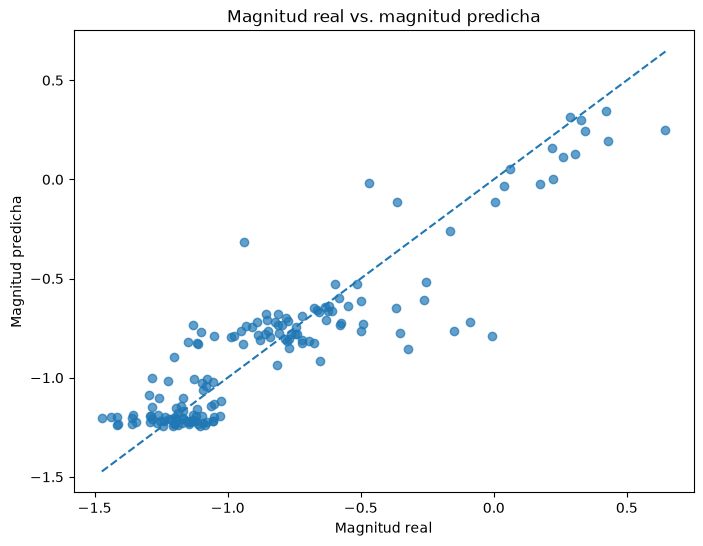

In [135]:
plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7
)


minimum_value = min(
    y_test.min(),
    y_test_pred.min()
)


maximum_value = max(
    y_test.max(),
    y_test_pred.max()
)


plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    linestyle="--"
)


plt.xlabel(
    "Magnitud real"
)


plt.ylabel(
    "Magnitud predicha"
)


plt.title(
    "Magnitud real vs. magnitud predicha"
)


plt.show()